# CLIP Surgery Demo — GeoCLIP & SatCLIP

This notebook shows how to compute CLIP-Surgery similarity maps for a single image and a single query GPS location.

Place your demo files in `notebooks/images`:
- `X.png` — any RGB city photo (GeoCLIP input)
- `X-satellite.tif` — Sentinel-2 GeoTIFF, 12 or 13 bands (SatCLIP input)
- `X-satellite.png` — optional RGB preview of the satellite tile for display

In [16]:
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from huggingface_hub import hf_hub_download
from PIL import Image

_CLIP_SURGERY_DIR = Path.cwd().parent / "src" / "explainability" / "clip_surgery"
if str(_CLIP_SURGERY_DIR) not in sys.path:
    sys.path.insert(0, str(_CLIP_SURGERY_DIR))

import _path_setup  # adds repo root and src/ to sys.path

from CLIP_Surgery import clip 
from geoclip_surgery import get_geoclip
from satclip_surgery.load import get_satclip
from inference_utils import (
    Location,
    _minmax_normalize,
    encode_locations,
    load_image_geoclip,
    load_image_sentinel,
    plot_similarity_maps,
    seed_everything,
    surgery_similarity_patch_rows,
)

SEED = 42
seed_everything(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


---
## Part 1 — GeoCLIP CLIP Surgery

GeoCLIP's image encoder is a HuggingFace Transformers CLIP ViT-L/14.  
The surgery replaces the standard attention in the **last 6 encoder layers** with
a dual-path V-V attention (`CLIPSurgeryAttention` in `geoclip_surgery/modeling_clip_surgery.py`).

Input: `X.png` — any RGB photo.  
Edit `QUERY_LON` / `QUERY_LAT` to match the actual location of the image.

In [17]:
geo_model = get_geoclip(device=DEVICE, surgery=True, return_all=True)
geo_model.eval()

vm_geo   = geo_model.image_encoder.CLIP.vision_model
vproj    = geo_model.image_encoder.CLIP.visual_projection
mlp_geo  = geo_model.image_encoder.mlp
encode_location_geo = geo_model.location_encoder.forward

print("GeoCLIP (surgery) loaded.")

Loading weights: 100%|██████████| 590/590 [00:01<00:00, 429.96it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/home/seri6958/miniconda3/envs/surgery/lib/python3.11/site-packages/geoclip/model/location_encoder.py:57: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details).

GeoCLIP (surgery) loaded.


In [18]:
CITY_IMAGE_PATH = "images/paris.jpg"

QUERY_LON = 2.2945   # Paris
QUERY_LAT = 48.8584

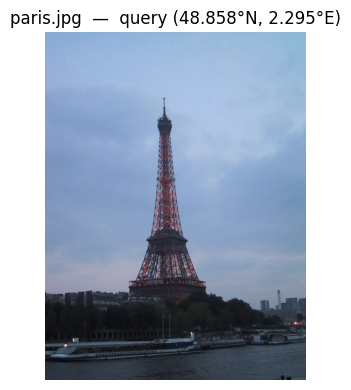

In [ ]:
image_geo = load_image_geoclip(CITY_IMAGE_PATH, device=DEVICE)
rgb_geo   = np.array(Image.open(CITY_IMAGE_PATH).convert("RGB"))
bgr_geo   = cv2.cvtColor(rgb_geo, cv2.COLOR_RGB2BGR)
h_geo, w_geo = rgb_geo.shape[:2]

query_loc_geo     = Location(id="query",     lon=QUERY_LON, lat=QUERY_LAT)
# we use the north pole location to simulate a null sample and extract noise
redundant_loc_geo = Location(id="north_pole", lon=0.0,      lat=90.0)

loc_feats_geo  = encode_locations([query_loc_geo],     encode_location_geo, DEVICE, satclip=False)
redund_geo     = encode_locations([redundant_loc_geo], encode_location_geo, DEVICE, satclip=False)

plt.figure(figsize=(5, 4))
plt.imshow(rgb_geo)
plt.title(f"{Path(CITY_IMAGE_PATH).name}  —  query ({QUERY_LAT:.3f}°N, {QUERY_LON:.3f}°E)")
plt.axis("off")
plt.tight_layout()
plt.show()

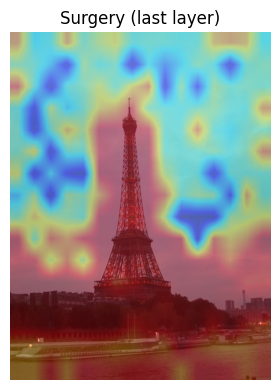

In [20]:
with torch.no_grad():
    vision_out, layer_hiddens_geo = vm_geo.forward_intermediates(
        pixel_values=image_geo,
        interpolate_pos_encoding=False,
    )
    patch_tokens = vproj(vm_geo.post_layernorm(vision_out.last_hidden_state))
    img_feats_geo = mlp_geo(patch_tokens)
    img_feats_geo = img_feats_geo / img_feats_geo.norm(dim=-1, keepdim=True)

    sim_geo = clip.clip_feature_surgery(img_feats_geo, loc_feats_geo, redundant_feats=redund_geo)
    sim_map_geo = clip.get_similarity_map(surgery_similarity_patch_rows(sim_geo), (h_geo, w_geo))

hm_geo = sim_map_geo[0, :, :, 0].cpu().numpy()
plot_similarity_maps([hm_geo], bgr_geo, titles=["Surgery (last layer)"], ncols=1, figsize=(5, 4), heatmap_normalize="minmax")

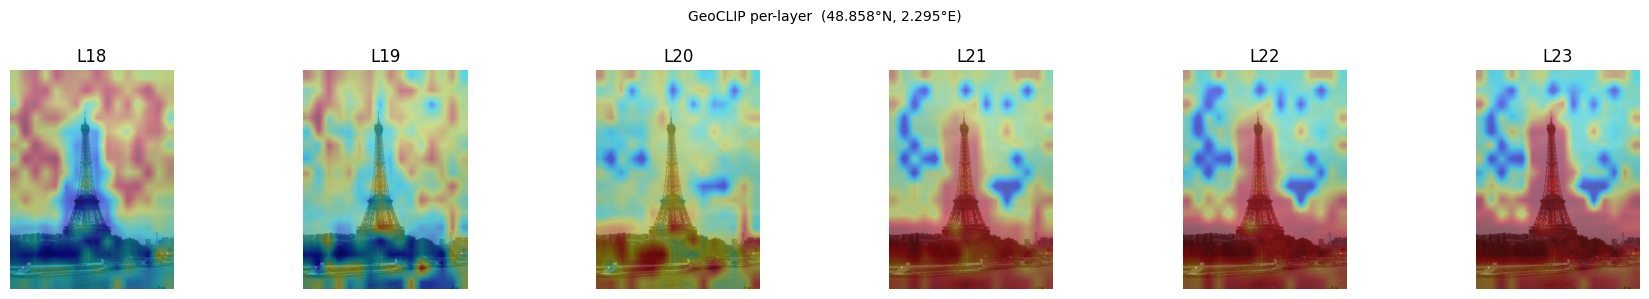

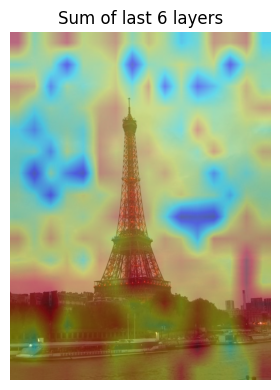

In [21]:
# per layer heatmaps
with torch.no_grad():
    heatmaps_geo, titles_geo, sum_hm_geo = [], [], None
    n_layers = len(layer_hiddens_geo)
    for li, hid in enumerate(layer_hiddens_geo[-6:]):
        feat = mlp_geo(vproj(vm_geo.post_layernorm(hid)))
        feat = feat / feat.norm(dim=-1, keepdim=True)
        sim  = clip.clip_feature_surgery(feat, loc_feats_geo, redundant_feats=redund_geo)
        smap = clip.get_similarity_map(surgery_similarity_patch_rows(sim), (h_geo, w_geo))
        hm   = smap[0, :, :, 0].cpu().numpy()
        heatmaps_geo.append(hm)
        titles_geo.append(f"L{n_layers - min(6, n_layers) + li}")
        sum_hm_geo = hm if sum_hm_geo is None else sum_hm_geo + hm

sum_geo = _minmax_normalize(sum_hm_geo).astype(np.float32)

plot_similarity_maps(
    heatmaps_geo, bgr_geo, titles=titles_geo,
    suptitle=f"GeoCLIP per-layer  ({QUERY_LAT:.3f}°N, {QUERY_LON:.3f}°E)",
    ncols=6, heatmap_normalize="minmax",
)
plot_similarity_maps(
    [sum_geo], bgr_geo, titles=["Sum of last 6 layers"],
    ncols=1, figsize=(5, 4),
)

---
## Part 2 — SatCLIP CLIP Surgery

SatCLIP's image encoder is a timm ViT-S/16 pretrained on Sentinel-2 images.  
The surgery replaces standard attention in the **last 6 timm blocks** with
`ConsistentAttention` (V-V attention, in `satclip_surgery/`).

Input: `X-satellite.tif` — a Sentinel-2 GeoTIFF (12 or 13 bands).  
`X-satellite.png` is used as the RGB display background; if absent the notebook
auto-generates one from bands 4, 3, 2 of the `.tif`.

In [ ]:
SATCLIP_CKPT = hf_hub_download("microsoft/SatCLIP-ViT16-L40", "satclip-vit16-l40.ckpt")
sat_model = get_satclip(SATCLIP_CKPT, device=DEVICE, surgery=True, return_all=True)
sat_model.eval()

vm_sat = sat_model.visual
encode_location_sat = sat_model.encode_location

/home/seri6958/explainable-earth-embeddings/src/explainability/clip_surgery/satclip_surgery/load.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_

using pretrained moco vit16 (surgery)
SatCLIP ViT16-L40 (surgery) loaded.


In [23]:
SATELLITE_TIF_PATH = "images/paris-satellite.tif"  
SATELLITE_PNG_PATH = "images/paris-satellite.png"   

QUERY_LON_SAT = 2.2945   # Paris
QUERY_LAT_SAT = 48.8584

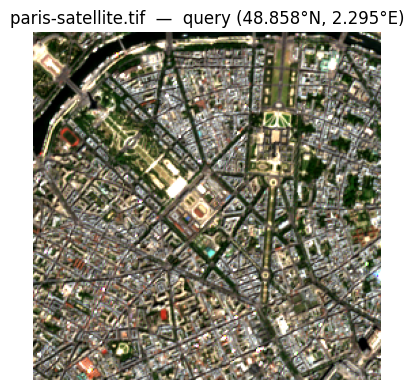

In [ ]:
image_sat, rgb_sat_auto = load_image_sentinel(SATELLITE_TIF_PATH, device=DEVICE)

rgb_sat = np.array(Image.open(SATELLITE_PNG_PATH).convert("RGB"))
bgr_sat = cv2.cvtColor(rgb_sat, cv2.COLOR_RGB2BGR)
h_sat, w_sat = rgb_sat.shape[:2]

query_loc_sat     = Location(id="query",      lon=QUERY_LON_SAT, lat=QUERY_LAT_SAT)
# we use the north pole location to simulate a null sample and extract noise
redundant_loc_sat = Location(id="north_pole", lon=0.0,           lat=90.0)

loc_feats_sat = encode_locations([query_loc_sat],     encode_location_sat, DEVICE, satclip=True)
redund_sat    = encode_locations([redundant_loc_sat], encode_location_sat, DEVICE, satclip=True)

plt.figure(figsize=(5, 4))
plt.imshow(rgb_sat)
plt.title(f"{Path(SATELLITE_TIF_PATH).name}  —  query ({QUERY_LAT_SAT:.3f}°N, {QUERY_LON_SAT:.3f}°E)")
plt.axis("off")
plt.tight_layout()
plt.show()

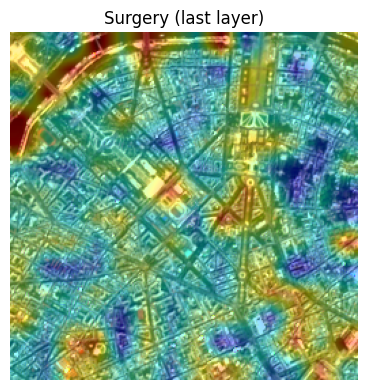

In [25]:
with torch.no_grad():
    final_tokens, layer_hiddens_sat = vm_sat.forward_intermediates(
        image_sat, indices=None, norm=False, output_fmt="NLC",
    )
    img_feats_sat = vm_sat.forward_head(final_tokens, pre_logits=False)
    img_feats_sat = img_feats_sat / img_feats_sat.norm(dim=-1, keepdim=True)

    sim_sat = clip.clip_feature_surgery(img_feats_sat, loc_feats_sat, redundant_feats=redund_sat)
    sim_map_sat = clip.get_similarity_map(surgery_similarity_patch_rows(sim_sat), (h_sat, w_sat))

hm_sat = sim_map_sat[0, :, :, 0].cpu().numpy()
plot_similarity_maps([hm_sat], bgr_sat, titles=["Surgery (last layer)"], ncols=1, figsize=(5, 4), heatmap_normalize="minmax")

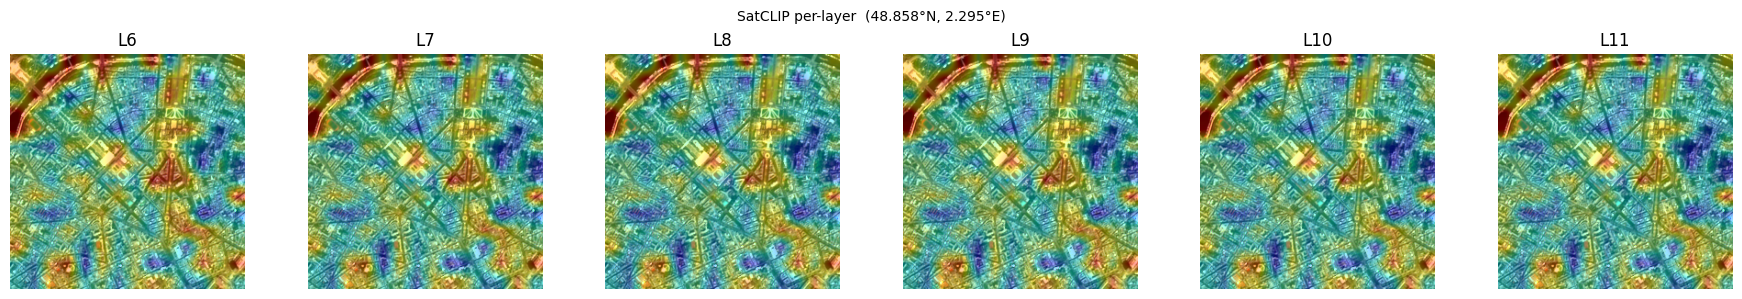

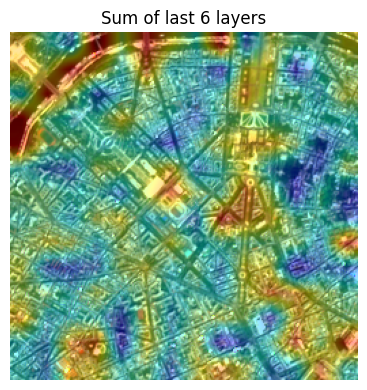

In [26]:
# per layer surgery maps
with torch.no_grad():
    heatmaps_sat, titles_sat, sum_hm_sat = [], [], None
    n_layers_sat = len(layer_hiddens_sat)
    for li, hid in enumerate(layer_hiddens_sat[-6:]):
        feat = vm_sat.forward_head(vm_sat.norm(hid), pre_logits=False)
        feat = feat / feat.norm(dim=-1, keepdim=True)
        sim  = clip.clip_feature_surgery(feat, loc_feats_sat, redundant_feats=redund_sat)
        smap = clip.get_similarity_map(surgery_similarity_patch_rows(sim), (h_sat, w_sat))
        hm   = smap[0, :, :, 0].cpu().numpy()
        heatmaps_sat.append(hm)
        titles_sat.append(f"L{n_layers_sat - min(6, n_layers_sat) + li}")
        sum_hm_sat = hm if sum_hm_sat is None else sum_hm_sat + hm

sum_sat = _minmax_normalize(sum_hm_sat).astype(np.float32)

plot_similarity_maps(
    heatmaps_sat, bgr_sat, titles=titles_sat,
    suptitle=f"SatCLIP per-layer  ({QUERY_LAT_SAT:.3f}°N, {QUERY_LON_SAT:.3f}°E)",
    ncols=6, heatmap_normalize="minmax",
)
plot_similarity_maps(
    [sum_sat], bgr_sat, titles=["Sum of last 6 layers"],
    ncols=1, figsize=(5, 4),
)